# Assignment 2: LSTM Autoencoder Anomaly Detection

This notebook uses the NSL-KDD network intrusion dataset. The task is framed as binary anomaly detection, where normal traffic is treated as class 0 and attack traffic as class 1.

The notebook trains two LSTM autoencoders on normal samples only, selects anomaly thresholds using a separate tuning split, evaluates on a final held-out test split, and compares the results with an Isolation Forest baseline.

In [16]:
import os
import json
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()

BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
PLOT_DIR = OUTPUT_DIR / "plots"
METRIC_DIR = OUTPUT_DIR / "metrics"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"

for folder in [DATA_DIR, OUTPUT_DIR, PLOT_DIR, METRIC_DIR, CHECKPOINT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Mixed precision:", USE_AMP)

Device: cuda
GPU: NVIDIA GeForce RTX 3070
Mixed precision: True


## 1. Load the dataset

NSL-KDD is used here as the selected network intrusion detection dataset. The code downloads the train and test files automatically if they are not already available locally.

In [17]:
TRAIN_FILE = DATA_DIR / "KDDTrain+.txt"
TEST_FILE = DATA_DIR / "KDDTest+.txt"

download_sources = {
    TRAIN_FILE: [
        "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt",
        "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt",
    ],
    TEST_FILE: [
        "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt",
        "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt",
    ],
}

def download_file(target_path, urls):
    if target_path.exists():
        print(f"{target_path} already exists")
        return
    last_error = None
    for url in urls:
        try:
            print(f"Downloading {target_path.name}")
            urllib.request.urlretrieve(url, target_path)
            print("Saved:", target_path)
            return
        except Exception as exc:
            last_error = exc
    raise RuntimeError(f"Could not download {target_path.name}. Last error: {last_error}")

for path, urls in download_sources.items():
    download_file(path, urls)

feature_columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate"
]

columns = feature_columns + ["label", "difficulty"]

train_raw = pd.read_csv(TRAIN_FILE, names=columns)
test_raw = pd.read_csv(TEST_FILE, names=columns)

print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)
train_raw.head()

Saved: data\KDDTrain+.txt
Saved: data\KDDTest+.txt
Train shape: (125973, 43)
Test shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 2. Preprocessing

The labels are converted into a binary setup. `normal` is treated as 0, and every attack type is treated as 1. Categorical features are one-hot encoded, and the scaler is fitted only on normal training rows to avoid using attack information during preprocessing.

In [18]:
def make_binary_labels(df):
    return (df["label"] != "normal").astype(int).values

y_train_rows = make_binary_labels(train_raw)
y_test_rows = make_binary_labels(test_raw)

X_train_raw = train_raw.drop(columns=["label", "difficulty"])
X_test_raw = test_raw.drop(columns=["label", "difficulty"])

missing_summary = {
    "train_missing_values": int(X_train_raw.isna().sum().sum()),
    "test_missing_values": int(X_test_raw.isna().sum().sum())
}

X_train_encoded = pd.get_dummies(X_train_raw, columns=["protocol_type", "service", "flag"])
X_test_encoded = pd.get_dummies(X_test_raw, columns=["protocol_type", "service", "flag"])
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

normal_train_mask = y_train_rows == 0

scaler = StandardScaler()
scaler.fit(X_train_encoded.loc[normal_train_mask])

X_train_scaled = scaler.transform(X_train_encoded).astype(np.float32)
X_test_scaled = scaler.transform(X_test_encoded).astype(np.float32)

print("Input dimension after encoding:", X_train_scaled.shape[1])
print("Normal rows in training set:", int(normal_train_mask.sum()))
print("Attack rows in training set:", int((~normal_train_mask).sum()))
print("Missing values:", missing_summary)

Input dimension after encoding: 122
Normal rows in training set: 67343
Attack rows in training set: 58630
Missing values: {'train_missing_values': 0, 'test_missing_values': 0}


## 3. Sequence preparation

The dataset is tabular, so sequences are created with a sliding window. For the mixed test data, the sequence label is taken from the last row of the window. This avoids the earlier problem where a whole window becomes anomalous if just one row inside it is anomalous.

In [19]:
SEQUENCE_LENGTH = 10

def make_sequences(X, y=None, sequence_length=10):
    X_seq = []
    y_seq = []
    for end_idx in range(sequence_length - 1, len(X)):
        start_idx = end_idx - sequence_length + 1
        X_seq.append(X[start_idx:end_idx + 1])
        if y is not None:
            y_seq.append(y[end_idx])
    X_seq = np.asarray(X_seq, dtype=np.float32)
    if y is None:
        return X_seq
    return X_seq, np.asarray(y_seq, dtype=np.int64)

X_train_normal_rows = X_train_scaled[normal_train_mask]

normal_sequence_data = make_sequences(
    X_train_normal_rows,
    sequence_length=SEQUENCE_LENGTH
)

normal_train_seq, normal_val_seq = train_test_split(
    normal_sequence_data,
    test_size=0.10,
    random_state=SEED,
    shuffle=True
)

X_test_seq_all, y_test_seq_all = make_sequences(
    X_test_scaled,
    y_test_rows,
    sequence_length=SEQUENCE_LENGTH
)

tune_idx, final_idx = train_test_split(
    np.arange(len(y_test_seq_all)),
    test_size=0.70,
    random_state=SEED,
    stratify=y_test_seq_all
)

X_tune_seq = X_test_seq_all[tune_idx]
y_tune_seq = y_test_seq_all[tune_idx]
X_final_seq = X_test_seq_all[final_idx]
y_final_seq = y_test_seq_all[final_idx]

data_summary = {
    "dataset": "NSL-KDD",
    "sequence_length": SEQUENCE_LENGTH,
    "train_rows_original": int(len(train_raw)),
    "test_rows_original": int(len(test_raw)),
    "normal_training_sequences": int(len(normal_train_seq)),
    "normal_validation_sequences": int(len(normal_val_seq)),
    "tuning_sequences_mixed": int(len(X_tune_seq)),
    "final_test_sequences_mixed": int(len(X_final_seq)),
    "tuning_anomaly_ratio": float(y_tune_seq.mean()),
    "final_test_anomaly_ratio": float(y_final_seq.mean()),
    "input_dim": int(X_train_scaled.shape[1]),
    **missing_summary
}

with open(METRIC_DIR / "data_summary.json", "w") as f:
    json.dump(data_summary, f, indent=4)

pd.DataFrame([data_summary])

,dataset,sequence_length,train_rows_original,test_rows_original,normal_training_sequences,normal_validation_sequences,tuning_sequences_mixed,final_test_sequences_mixed,tuning_anomaly_ratio,final_test_anomaly_ratio,input_dim,train_missing_values,test_missing_values
0,NSL-KDD,10,125973,22544,60600,6734,6760,15775,0.569231,0.569255,122,0,0


## 4. Data loaders

In [20]:
BATCH_SIZE = 256

def make_loader(X, batch_size=BATCH_SIZE, shuffle=True):
    tensor_x = torch.tensor(X, dtype=torch.float32)
    dataset = TensorDataset(tensor_x)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=False)

train_loader = make_loader(normal_train_seq, shuffle=True)
val_loader = make_loader(normal_val_seq, shuffle=False)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 237
Validation batches: 27


## 5. LSTM autoencoder models

The first model is smaller and uses a single LSTM layer. The second model has a deeper encoder/decoder structure and a smaller latent representation. The point is to compare whether adding depth and compression improves the anomaly score.

In [21]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=32, num_layers=1, dropout=0.0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.num_layers = num_layers

        lstm_dropout = dropout if num_layers > 1 else 0.0

        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=lstm_dropout,
            batch_first=True
        )

        self.to_latent = nn.Linear(hidden_dim, latent_dim)
        self.from_latent = nn.Linear(latent_dim, hidden_dim)

        self.decoder = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=lstm_dropout,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        seq_len = x.shape[1]
        _, (hidden, _) = self.encoder(x)
        z = self.to_latent(hidden[-1])
        repeated = self.from_latent(z).unsqueeze(1).repeat(1, seq_len, 1)
        decoded, _ = self.decoder(repeated)
        return self.output_layer(decoded)

input_dim = X_train_scaled.shape[1]

model_small = LSTMAutoencoder(
    input_dim=input_dim,
    hidden_dim=64,
    latent_dim=32,
    num_layers=1,
    dropout=0.0
).to(DEVICE)

model_deep = LSTMAutoencoder(
    input_dim=input_dim,
    hidden_dim=128,
    latent_dim=32,
    num_layers=2,
    dropout=0.2
).to(DEVICE)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Small model parameters:", count_parameters(model_small))
print("Deep model parameters:", count_parameters(model_deep))

Small model parameters: 93530
Deep model parameters: 549402


## 6. Training

In [22]:
EPOCHS = 40
PATIENCE = 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_count = 0
    criterion = nn.MSELoss(reduction="mean")

    for (batch,) in loader:
        batch = batch.to(DEVICE)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            if USE_AMP:
                with torch.amp.autocast(device_type="cuda"):
                    reconstructed = model(batch)
                    loss = criterion(reconstructed, batch)
            else:
                reconstructed = model(batch)
                loss = criterion(reconstructed, batch)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * batch.size(0)
        total_count += batch.size(0)

    return total_loss / total_count

def train_model(model, model_name):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    history = {"train_loss": [], "val_loss": []}
    best_val = float("inf")
    best_state = None
    wait = 0

    for epoch in range(EPOCHS):
        train_loss = run_epoch(model, train_loader, optimizer)
        val_loss = run_epoch(model, val_loader)

        history["train_loss"].append(float(train_loss))
        history["val_loss"].append(float(val_loss))

        print(
            f"{model_name} | Epoch {epoch + 1:02d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}"
        )

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Early stopping for {model_name}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    torch.save(model.state_dict(), CHECKPOINT_DIR / f"{model_name}.pth")

    with open(METRIC_DIR / f"{model_name}_history.json", "w") as f:
        json.dump(history, f, indent=4)

    return model, history

model_small, history_small = train_model(model_small, "lstm_ae_small")
model_deep, history_deep = train_model(model_deep, "lstm_ae_deep")

lstm_ae_small | Epoch 01/40 | Train Loss: 0.591967 | Val Loss: 0.550632
lstm_ae_small | Epoch 02/40 | Train Loss: 0.535216 | Val Loss: 0.499482
lstm_ae_small | Epoch 03/40 | Train Loss: 0.499202 | Val Loss: 0.472739
lstm_ae_small | Epoch 04/40 | Train Loss: 0.481426 | Val Loss: 0.457889
lstm_ae_small | Epoch 05/40 | Train Loss: 0.468025 | Val Loss: 0.454470
lstm_ae_small | Epoch 06/40 | Train Loss: 0.460327 | Val Loss: 0.441250
lstm_ae_small | Epoch 07/40 | Train Loss: 0.450804 | Val Loss: 0.437205
lstm_ae_small | Epoch 08/40 | Train Loss: 0.448878 | Val Loss: 0.428777
lstm_ae_small | Epoch 09/40 | Train Loss: 0.441169 | Val Loss: 0.422359
lstm_ae_small | Epoch 10/40 | Train Loss: 0.437348 | Val Loss: 0.426586
lstm_ae_small | Epoch 11/40 | Train Loss: 0.438647 | Val Loss: 0.424404
lstm_ae_small | Epoch 12/40 | Train Loss: 0.430983 | Val Loss: 0.412338
lstm_ae_small | Epoch 13/40 | Train Loss: 0.425479 | Val Loss: 0.410588
lstm_ae_small | Epoch 14/40 | Train Loss: 0.422648 | Val Loss: 0

## 7. Training-history plots

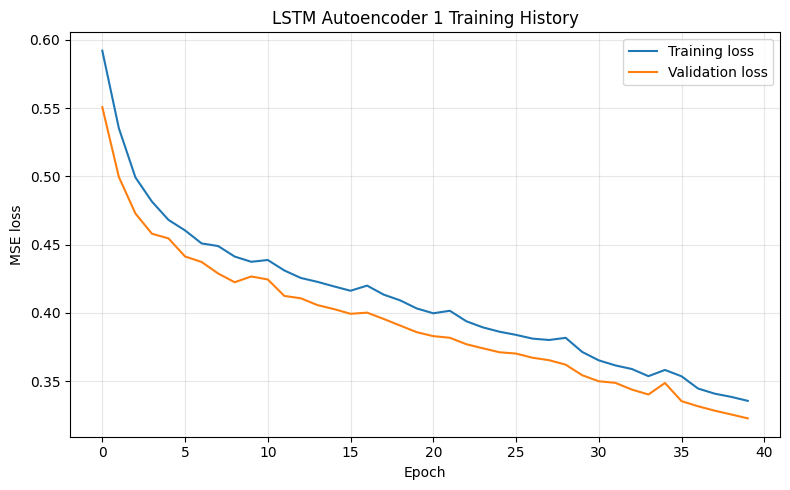

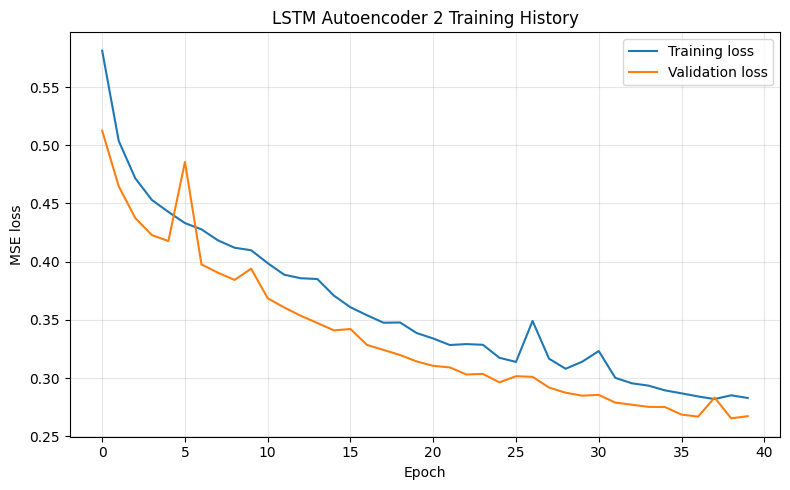

In [23]:
def plot_history(history, title, filename):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Training loss")
    plt.plot(history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / filename, dpi=300)
    plt.show()

plot_history(history_small, "LSTM Autoencoder 1 Training History", "lstm_ae_small_training_history.png")
plot_history(history_deep, "LSTM Autoencoder 2 Training History", "lstm_ae_deep_training_history.png")

## 8. Reconstruction errors and threshold selection

The threshold is selected on the tuning split by sweeping possible threshold values and choosing the one that gives the best F1-score. The final metrics are then calculated only on the final test split.

In [24]:
def reconstruction_errors(model, X, batch_size=512):
    model.eval()
    loader = make_loader(X, batch_size=batch_size, shuffle=False)
    errors = []

    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            reconstructed = model(batch)
            batch_errors = torch.mean((reconstructed - batch) ** 2, dim=(1, 2))
            errors.extend(batch_errors.detach().cpu().numpy())

    return np.asarray(errors)

def best_threshold(scores, labels):
    candidates = np.quantile(scores, np.linspace(0.05, 0.995, 250))
    best_f1 = -1.0
    best_t = candidates[0]

    for t in candidates:
        preds = (scores > t).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return float(best_t), float(best_f1)

small_tune_scores = reconstruction_errors(model_small, X_tune_seq)
small_final_scores = reconstruction_errors(model_small, X_final_seq)

deep_tune_scores = reconstruction_errors(model_deep, X_tune_seq)
deep_final_scores = reconstruction_errors(model_deep, X_final_seq)

threshold_small, tune_f1_small = best_threshold(small_tune_scores, y_tune_seq)
threshold_deep, tune_f1_deep = best_threshold(deep_tune_scores, y_tune_seq)

print("Small AE threshold:", threshold_small, "Tuning F1:", tune_f1_small)
print("Deep AE threshold:", threshold_deep, "Tuning F1:", tune_f1_deep)

Small AE threshold: 0.6937977105379105 Tuning F1: 0.724634858812074
Deep AE threshold: 0.5414999425411224 Tuning F1: 0.7244401168451802


## 9. Isolation Forest baseline

In [25]:
X_train_flat = normal_train_seq.reshape(normal_train_seq.shape[0], -1)
X_tune_flat = X_tune_seq.reshape(X_tune_seq.shape[0], -1)
X_final_flat = X_final_seq.reshape(X_final_seq.shape[0], -1)

isolation_forest = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=SEED,
    n_jobs=-1
)

isolation_forest.fit(X_train_flat)

iso_tune_scores = -isolation_forest.decision_function(X_tune_flat)
iso_final_scores = -isolation_forest.decision_function(X_final_flat)

threshold_iso, tune_f1_iso = best_threshold(iso_tune_scores, y_tune_seq)

print("Isolation Forest threshold:", threshold_iso, "Tuning F1:", tune_f1_iso)

Isolation Forest threshold: -0.11185502620884863 Tuning F1: 0.7232716650438169


## 10. Evaluation

In [26]:
def evaluate_scores(model_name, scores, labels, threshold):
    preds = (scores > threshold).astype(int)

    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    try:
        roc_auc = roc_auc_score(labels, scores)
    except ValueError:
        roc_auc = np.nan

    try:
        auc_pr = average_precision_score(labels, scores)
    except ValueError:
        auc_pr = np.nan

    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()

    return {
        "model": model_name,
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "roc_auc": float(roc_auc),
        "auc_pr": float(auc_pr),
        "threshold": float(threshold),
        "TP": int(tp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn)
    }

results = [
    evaluate_scores("lstm_ae_small", small_final_scores, y_final_seq, threshold_small),
    evaluate_scores("lstm_ae_deep", deep_final_scores, y_final_seq, threshold_deep),
    evaluate_scores("isolation_forest", iso_final_scores, y_final_seq, threshold_iso)
]

results_df = pd.DataFrame(results)

results_df.to_csv(METRIC_DIR / "evaluation_results.csv", index=False)
with open(METRIC_DIR / "evaluation_results.json", "w") as f:
    json.dump({row["model"]: {k: v for k, v in row.items() if k != "model"} for row in results}, f, indent=4)

results_df

,model,precision,recall,f1_score,roc_auc,auc_pr,threshold,TP,TN,FP,FN
0,lstm_ae_small,0.583944,0.967929,0.728431,0.596148,0.625096,0.693798,8692,602,6193,288
1,lstm_ae_deep,0.581952,0.969488,0.727318,0.594885,0.624963,0.541500,8706,541,6254,274
2,isolation_forest,0.580710,0.965479,0.725220,0.595420,0.643702,-0.111855,8670,535,6260,310


## 11. Reconstruction-error and anomaly-score plots

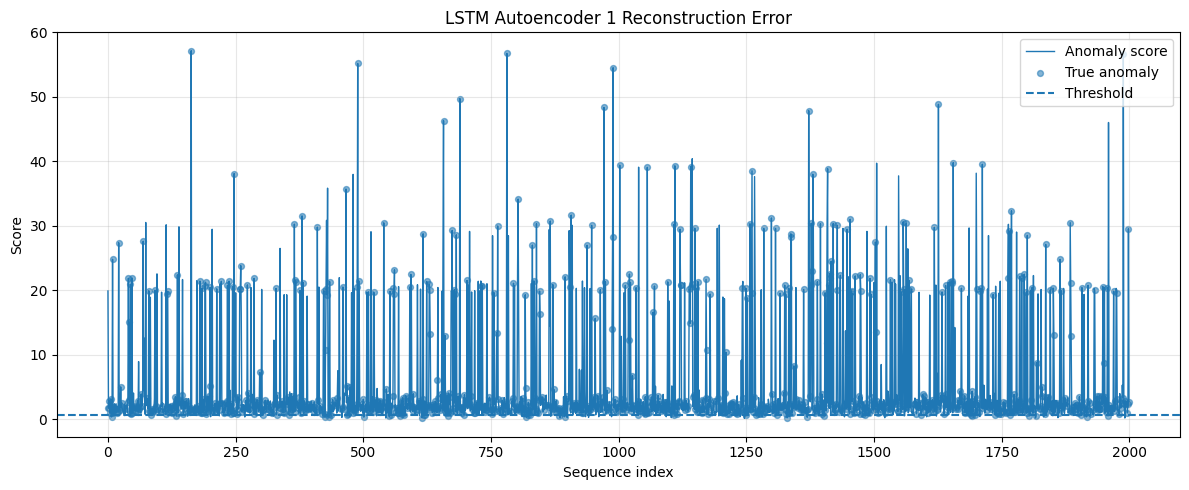

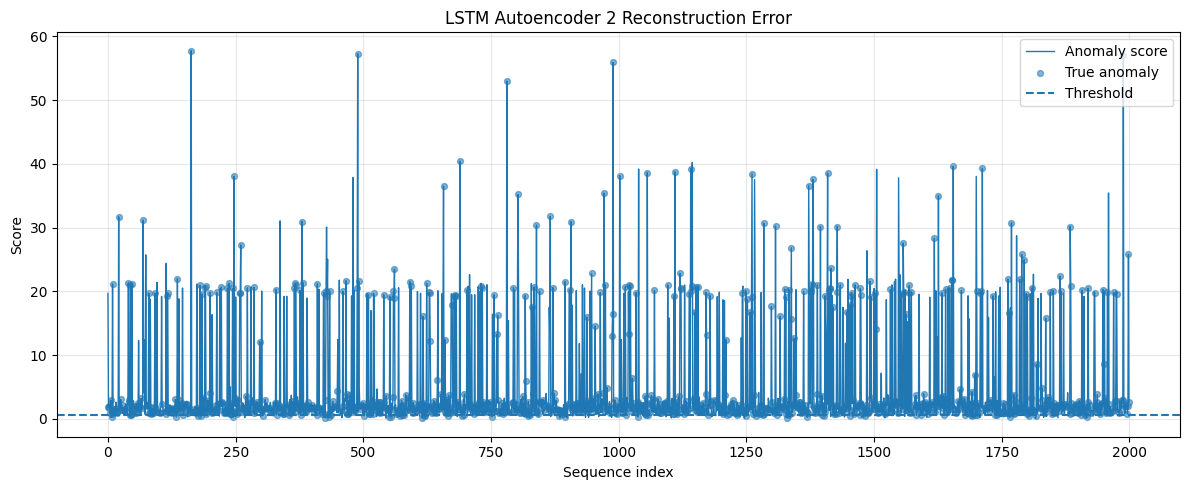

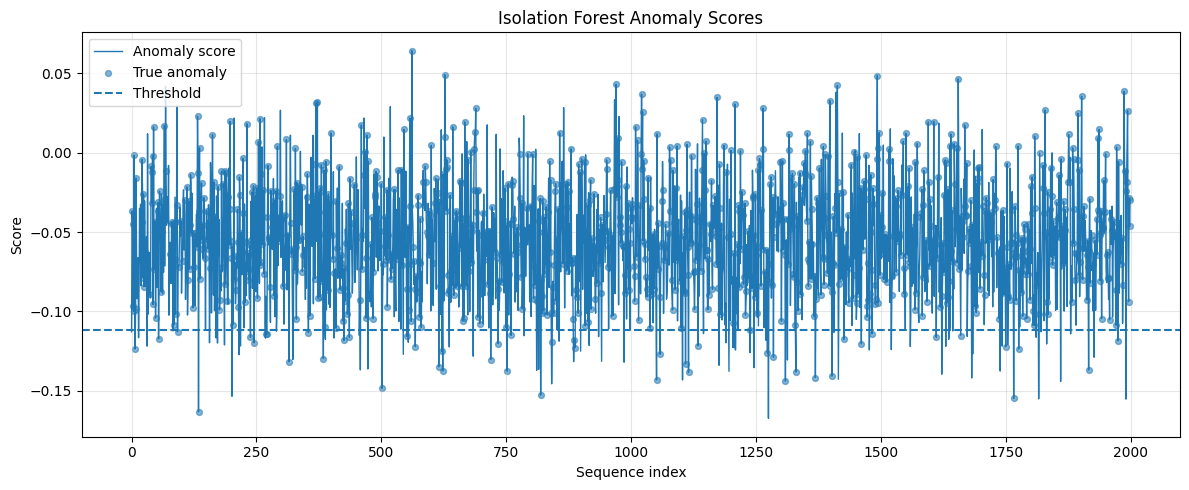

In [27]:
def plot_score_series(scores, labels, threshold, title, filename, max_points=2000):
    n = min(max_points, len(scores))
    idx = np.arange(n)
    labels_n = labels[:n]
    scores_n = scores[:n]

    plt.figure(figsize=(12, 5))
    plt.plot(idx, scores_n, linewidth=1.0, label="Anomaly score")
    anomaly_idx = idx[labels_n == 1]
    plt.scatter(
        anomaly_idx,
        scores_n[labels_n == 1],
        s=18,
        alpha=0.55,
        label="True anomaly"
    )
    plt.axhline(threshold, linestyle="--", linewidth=1.5, label="Threshold")
    plt.xlabel("Sequence index")
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / filename, dpi=300)
    plt.show()

plot_score_series(
    small_final_scores,
    y_final_seq,
    threshold_small,
    "LSTM Autoencoder 1 Reconstruction Error",
    "lstm_ae_small_reconstruction_error.png"
)

plot_score_series(
    deep_final_scores,
    y_final_seq,
    threshold_deep,
    "LSTM Autoencoder 2 Reconstruction Error",
    "lstm_ae_deep_reconstruction_error.png"
)

plot_score_series(
    iso_final_scores,
    y_final_seq,
    threshold_iso,
    "Isolation Forest Anomaly Scores",
    "isolation_forest_anomaly_scores.png"
)

## 12. Error distribution histograms

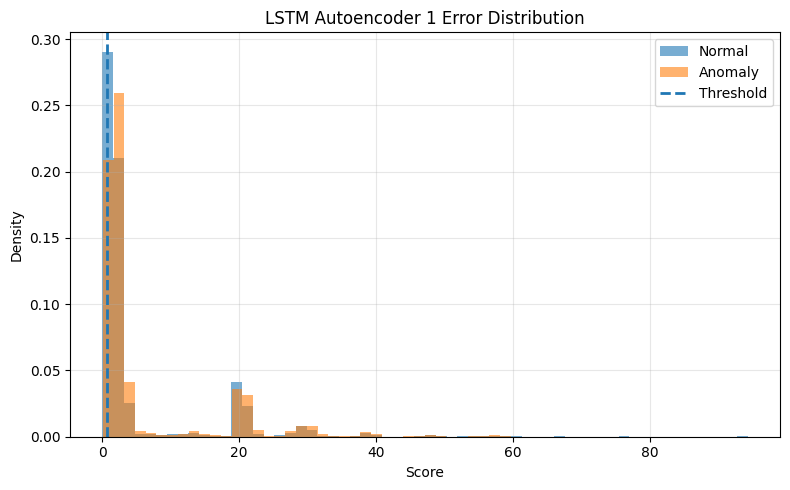

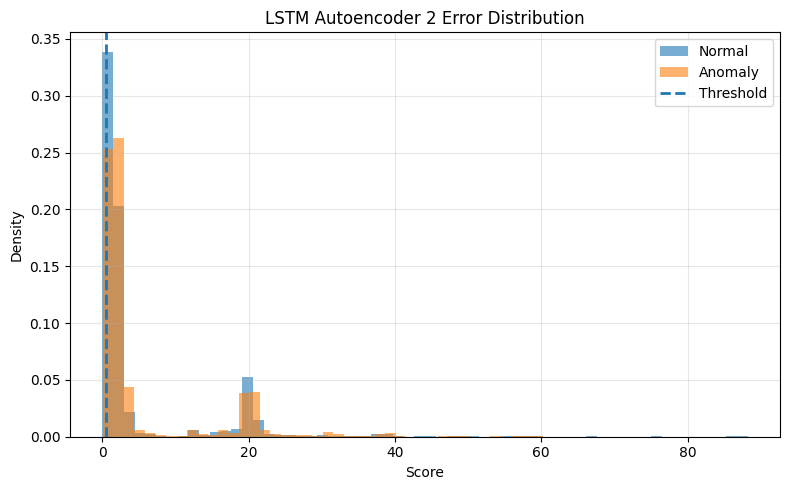

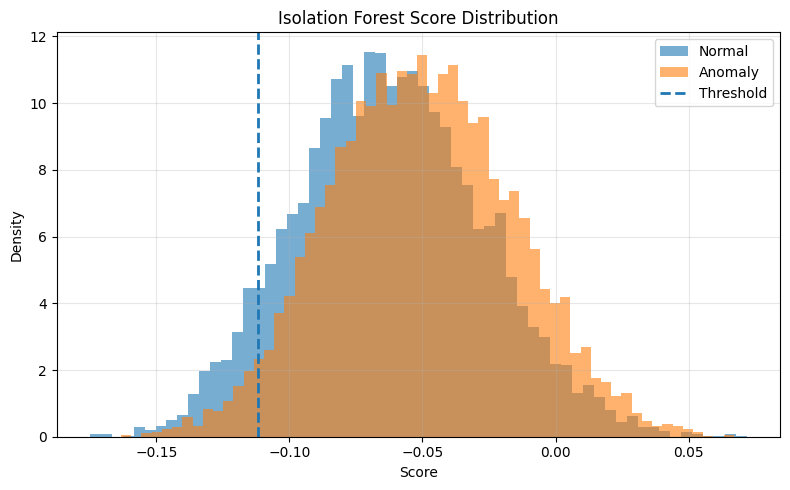

In [28]:
def plot_score_histogram(scores, labels, threshold, title, filename):
    normal_scores = scores[labels == 0]
    anomaly_scores = scores[labels == 1]

    plt.figure(figsize=(8, 5))
    plt.hist(normal_scores, bins=60, alpha=0.6, density=True, label="Normal")
    plt.hist(anomaly_scores, bins=60, alpha=0.6, density=True, label="Anomaly")
    plt.axvline(threshold, linestyle="--", linewidth=2, label="Threshold")
    plt.xlabel("Score")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / filename, dpi=300)
    plt.show()

plot_score_histogram(
    small_final_scores,
    y_final_seq,
    threshold_small,
    "LSTM Autoencoder 1 Error Distribution",
    "lstm_ae_small_error_histogram.png"
)

plot_score_histogram(
    deep_final_scores,
    y_final_seq,
    threshold_deep,
    "LSTM Autoencoder 2 Error Distribution",
    "lstm_ae_deep_error_histogram.png"
)

plot_score_histogram(
    iso_final_scores,
    y_final_seq,
    threshold_iso,
    "Isolation Forest Score Distribution",
    "isolation_forest_score_histogram.png"
)

## 13. Comparison plots

<Figure size 1000x500 with 0 Axes>

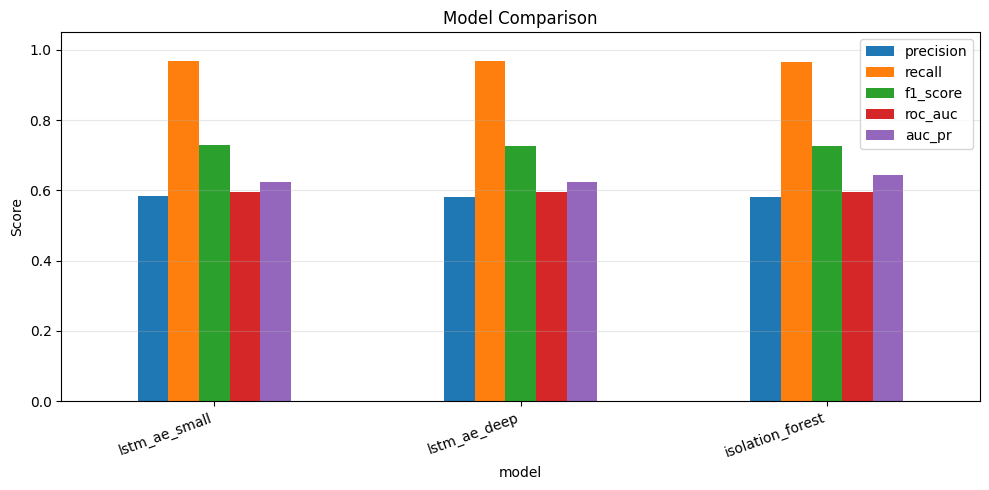

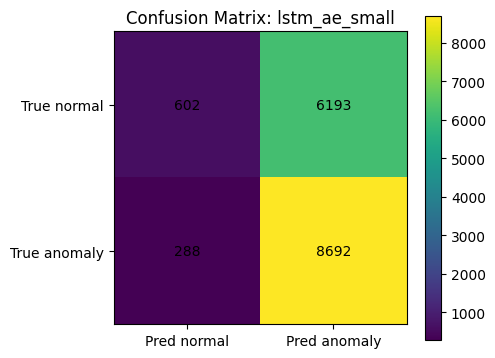

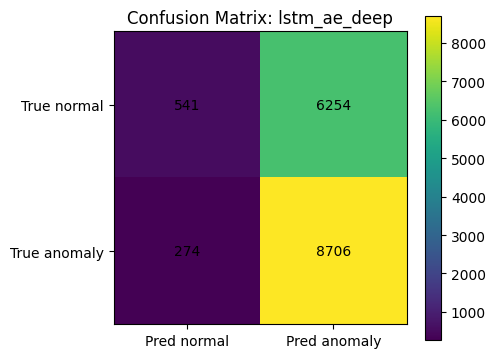

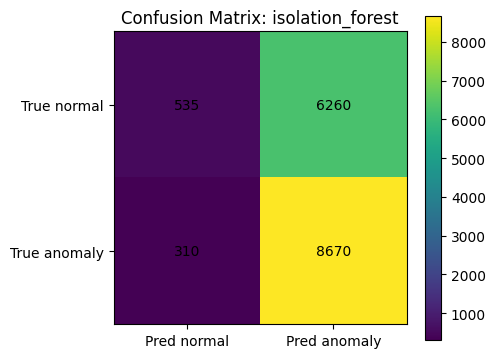

In [29]:
comparison_df = results_df.set_index("model")[["precision", "recall", "f1_score", "roc_auc", "auc_pr"]]

plt.figure(figsize=(10, 5))
comparison_df.plot(kind="bar", figsize=(10, 5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "model_comparison.png", dpi=300)
plt.show()

def plot_confusion_matrix_for_model(result, title, filename):
    matrix = np.array([[result["TN"], result["FP"]], [result["FN"], result["TP"]]])

    plt.figure(figsize=(5, 4))
    plt.imshow(matrix)
    plt.title(title)
    plt.xticks([0, 1], ["Pred normal", "Pred anomaly"])
    plt.yticks([0, 1], ["True normal", "True anomaly"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(matrix[i, j]), ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / filename, dpi=300)
    plt.show()

for result in results:
    plot_confusion_matrix_for_model(
        result,
        f"Confusion Matrix: {result['model']}",
        f"{result['model']}_confusion_matrix.png"
    )

## 14. Saved files

In [30]:
print("Saved metrics:")
for path in sorted(METRIC_DIR.glob("*")):
    print("-", path)

print("\nSaved plots:")
for path in sorted(PLOT_DIR.glob("*")):
    print("-", path)

Saved metrics:
- outputs\metrics\data_summary.json
- outputs\metrics\evaluation_results.csv
- outputs\metrics\evaluation_results.json
- outputs\metrics\lstm_ae_deep_history.json
- outputs\metrics\lstm_ae_small_history.json

Saved plots:
- outputs\plots\isolation_forest_anomaly_scores.png
- outputs\plots\isolation_forest_confusion_matrix.png
- outputs\plots\isolation_forest_score_histogram.png
- outputs\plots\lstm_ae_deep_confusion_matrix.png
- outputs\plots\lstm_ae_deep_error_histogram.png
- outputs\plots\lstm_ae_deep_reconstruction_error.png
- outputs\plots\lstm_ae_deep_training_history.png
- outputs\plots\lstm_ae_small_confusion_matrix.png
- outputs\plots\lstm_ae_small_error_histogram.png
- outputs\plots\lstm_ae_small_reconstruction_error.png
- outputs\plots\lstm_ae_small_training_history.png
- outputs\plots\model_comparison.png
